# **Live Coding BAB 7 Metode Evaluasi Klasifikasi**

- Nama    : Sayyidah Fatimah Azzahra
- NIM     : 235150200111064
- Kelas   : TIF-E

## **1. Import Library**

**Import library standar yang diperlukan, seperti pandas, numpy, dan sebagainya**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pprint import pprint

## **2. Load Dataset**

**a. Import dataset dari link yang sudah diberikan, dibebaskan menggunakan metode apapun untuk loading dataset.**

In [2]:
df = pd.read_csv('dataset/spaceship_train.csv')

**Tentang Dataset**

The dataset is Spaceship Titanic, a dataset for classification/prediction of whether a passenger was rescued (Transported=True) or not (Transported=False). This dataset is inspired by the Titanic concept but set in outer space. It consists of several columns/features:

*   PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
*   HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
*   CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
*   Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
*   Destination - The planet the passenger will be debarking to.
*   Age - The age of the passenger.
*   VIP - Whether the passenger has paid for special VIP service during the voyage.
*   RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
*   Name - The first and last names of the passenger.
*   Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

**b. *Cetak* dataset**

In [3]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**c. *Deskripsi* dataset**

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.00000

## **3. Preprocessing**

**a. Ambil indeks fitur numerik dan kategorikal**

In [5]:
df.drop(columns=['PassengerId', 'Cabin', 'Name'], inplace=True)

In [6]:
fitur_numerik = df.select_dtypes(include=['number']).columns
fitur_kategorikal = df.select_dtypes(exclude=['number']).columns

print("Fitur Numerik: ", fitur_numerik)
print("Fitur Kategorikal: ", fitur_kategorikal)

Fitur Numerik:  Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')
Fitur Kategorikal:  Index(['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported'], dtype='object')


**b. Transformasi nilai 0 ke NaN untuk data numerik**

In [7]:
df = df.replace(0, np.nan)

**c. Missing Value**

In [8]:
print(df.isnull().sum())

HomePlanet       201
CryoSleep       5656
Destination      182
Age              357
VIP             8494
RoomService     5758
FoodCourt       5639
ShoppingMall    5795
Spa             5507
VRDeck          5683
Transported        0
dtype: int64


Lakukan imputasi data, dengan ketentuan untuk fitur numerik, data NaN diubah menggunakan fungsi **mean** serta untuk fitur kategorikal, data NaN diubah menggunakan fungsi **modus/mode**

In [9]:
def imputasi(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)
    return df

In [10]:
df = imputasi(df)

/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_29074/1518405833.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_29074/1518405833.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].

In [11]:
print("Setelah Imputasi:")
print(df.isnull().sum())

Setelah Imputasi:
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64


**d. Outlier Handling**

In [12]:
def handle_outliers(df):

    for col in fitur_numerik:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return df

In [13]:
df = handle_outliers(df)

**e. Normalisasi Data**

In [14]:
def minmax_normalization(column):
    return (column - column.min()) / (column.max() - column.min())

In [15]:
for column in fitur_numerik:
    df[column] = minmax_normalization(df[column])

**b. Lakukan label encoding untuk fitur/kolom kategorikal!**

In [16]:
label_encoder = LabelEncoder()
df = df.apply(label_encoder.fit_transform)

**c. Ubah kolom target, yang awalnya boolean menjadi integer**

In [17]:
df['Transported'] = df['Transported'].astype(int)

## **4. Split Dataset**

Ambil sample data sebanyak 3000 dengan memperhatikan distribusi kelas.
Lalu pisahkan dataset menjadi data latih dan data uji

In [18]:
sampled_df, _ = train_test_split(df, train_size=3000, stratify=df['Transported'], random_state=42)

In [19]:
data_latih, data_uji = train_test_split(sampled_df,test_size=0.2,random_state=42)
data_latih = data_latih.reset_index(drop=True)
data_uji = data_uji.reset_index(drop=True)

## **7. XGBoost**

Lakukan klasifikasi menggunakan XGBoost

**a. Import Library**

In [20]:
import xgboost as xgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

**b. Pisahkan Fitur dengan Label**

In [21]:
X, y = sampled_df.drop('Transported', axis=1), sampled_df['Transported']

**c. Split Data**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**d. Buat Model/Classifier XGB**

In [23]:
model = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')

**e. Pengujian**

In [24]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

Accuracy: 0.67


**f. Feature Importance XGB**

Lakukan Visualisasi Feature Importance menggunakan fungsi yang disediakan di XGB.

<Figure size 1000x600 with 0 Axes>

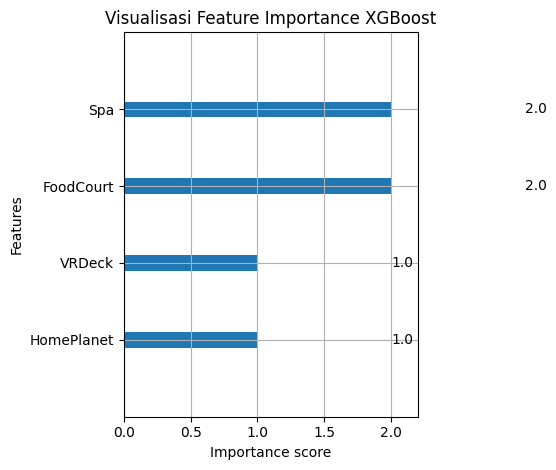

In [26]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model)
plt.title('Visualisasi Feature Importance XGBoost')
plt.tight_layout()
plt.show()

***Pertanyaan***

Visualisasi apa yang diberikan dan jelaskan!

Jawaban:

Visualisasi yang ditampilkan adalah diagram batang horizontal yang mengurutkan fitur berdasarkan tingkat kepentingannya dalam model. Batang yang lebih panjang menunjukkan fitur yang lebih berpengaruh dalam pengambilan keputusan model.

**f. Hyperparameter Tuning**

Hyperparameter tuning adalah proses mencari kombinasi terbaik dari parameter eksternal dalam model machine learning agar model memiliki performa terbaik. Salah satu metodenya adalah GridSearch, dimana metode ini mencoba semua kombinasi dari parameter yang diberikan dan memilih yang terbaik berdasarkan metrik evaluasi misalnya akurasi .

In [27]:
# Daftar hyperparameter yang akan diuji
n_estimators_list = [100, 200, 300]
max_depth_list = [3, 5, 7]
learning_rate_list = [0.01, 0.1, 0.2]

# Variabel untuk menyimpan hasil terbaik
best_params = None
best_accuracy = 0

# Looping untuk mencoba semua kombinasi hyperparameter
for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            # Inisialisasi model dengan hyperparameter saat ini
            model = xgb.XGBClassifier(n_estimators=n, max_depth=depth, learning_rate=lr)

            # Latih model
            model.fit(X_train, y_train)

            # Evaluasi model
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)

            # Simpan kombinasi terbaik
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {'n_estimators': n, 'max_depth': depth, 'learning_rate': lr}

            print(f"n_estimators={n}, max_depth={depth}, learning_rate={lr} → Accuracy: {accuracy:.4f}")

# Print hasil terbaik
print("\nBest Parameters:", best_params)
print("Best Accuracy:", best_accuracy)


n_estimators=100, max_depth=3, learning_rate=0.01 → Accuracy: 0.6917
n_estimators=100, max_depth=3, learning_rate=0.1 → Accuracy: 0.7100
n_estimators=100, max_depth=3, learning_rate=0.2 → Accuracy: 0.7050
n_estimators=100, max_depth=5, learning_rate=0.01 → Accuracy: 0.7050
n_estimators=100, max_depth=5, learning_rate=0.1 → Accuracy: 0.7117
n_estimators=100, max_depth=5, learning_rate=0.2 → Accuracy: 0.7000
n_estimators=100, max_depth=7, learning_rate=0.01 → Accuracy: 0.7167
n_estimators=100, max_depth=7, learning_rate=0.1 → Accuracy: 0.6933
n_estimators=100, max_depth=7, learning_rate=0.2 → Accuracy: 0.6867
n_estimators=200, max_depth=3, learning_rate=0.01 → Accuracy: 0.7033
n_estimators=200, max_depth=3, learning_rate=0.1 → Accuracy: 0.7000
n_estimators=200, max_depth=3, learning_rate=0.2 → Accuracy: 0.6867
n_estimators=200, max_depth=5, learning_rate=0.01 → Accuracy: 0.7083
n_estimators=200, max_depth=5, learning_rate=0.1 → Accuracy: 0.6967
n_estimators=200, max_depth=5, learning_rat

***Pertanyaan***

Apa manfaat dan kelemahan dari Hyperparameter Tuning menggunakan GridSearch?

Jawaban:
Utamanya, kita bisa mengeksplorasi lebih banyak kombinasi hyperparameter yang mungkin secara otomatis dengan jaminan hasil yang optimal. Namun, untuk grid yang besar, komputasinya mahal dan memakan waktu. Selain itu, kita harus menentukan rentang hyperparameter yang akan kita eksplorasi dan ada risiko terjadi overfitting pada data validasi yang kita gunakan.

Dalam kasus saya, hasil akurasi model meningkat dari 67% menjadi 71% dengan hyperparameter tuning menggunakan GridSearch.

## **Metode Evaluasi Klasifikasi**

1. Gunakan notebook pada Live Coding BAB 5, ambil klasifikasi yang menggunakan XGBoost saja

2. Lakukan prediksi model.predict() dari XGBoost untuk dievaluasi menggunakan metode:

- Confusion Matrix
- Precision, recall, f1-score, accuracy per kelas
- F1-score dan akurasi rata-rata MCC per kelas

3. Lakukan prediksi model.predict_proba() xgboost untuk dievaluasi menggunakan metode  ROC-AUC beserta plot kurva ROC dan area AUC

4. Berikan penjelasan terhadap hasil masing-masing evaluasi

In [28]:
y_pred = model.predict(X_test)
y_true = y_test

labels = [0, 1]

In [29]:
def confusion_matrix_multiclass(y_true, y_pred, labels):
    num_classes = len(labels)
    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
    
    for true, pred in zip(y_true, y_pred):
        confusion_matrix[true, pred] += 1
    
    return confusion_matrix

def calculate_metrics(confusion_matrix):
    num_classes = confusion_matrix.shape[0]
    metrics = {}
    
    # Untuk menyimpan nilai global
    total_TP = 0
    total_FP = 0
    total_FN = 0
    total_TN = 0
    total_f1 = 0

    for i in range(num_classes):
        TP = confusion_matrix[i, i]
        FP = confusion_matrix[:, i].sum() - TP
        FN = confusion_matrix[i, :].sum() - TP
        TN = confusion_matrix.sum() - (TP + FP + FN)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (TP + TN) / (TP + TN + FP + FN)

        metrics[labels[i]] = {
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1_score,
            "Accuracy": accuracy
        }
        
        # Akumulasi untuk perhitungan rata-rata
        total_TP += TP
        total_FP += FP
        total_FN += FN
        total_TN += TN
        total_f1 += f1_score
    
    # Menghitung metrik rata-rata
    avg_f1 = total_f1 / num_classes
    avg_accuracy = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN)
    
    # Menambahkan metrik rata-rata ke dalam dictionary
    metrics['average'] = {
        "F1-score": avg_f1,
        "Accuracy": avg_accuracy
    }
    
    # Menghitung MCC (Matthews Correlation Coefficient)
    if num_classes == 2:
        TP = metrics[1]["TP"]
        TN = metrics[0]["TP"] 
        FP = metrics[1]["FP"]
        FN = metrics[1]["FN"]
        
        numerator = (TP * TN) - (FP * FN)
        denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
        mcc = numerator / denominator if denominator != 0 else 0
        
        metrics['MCC'] = mcc
    
    return metrics

confusion_matrix = confusion_matrix_multiclass(y_true, y_pred, labels)
metrics = calculate_metrics(confusion_matrix)

In [30]:
print(confusion_matrix)

[[201  97]
 [106 196]]


In [31]:
for label, metric in metrics.items():
    if label != 'average' and label != 'MCC':
        print(f"\nClass {label}:")
        for key, value in metric.items():
            print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

print("\nAverage Metrics:")
print(f"F1-Score: {metrics['average']['F1-score']:.4f}")
print(f"Accuracy: {metrics['average']['Accuracy']:.4f}")

if 'MCC' in metrics:
    print(f"\nMatthews Correlation Coefficient: {metrics['MCC']:.4f}")


Class 0:
TP: 201
FP: 106
FN: 97
TN: 196
Precision: 0.6547
Recall: 0.6745
F1-score: 0.6645
Accuracy: 0.6617

Class 1:
TP: 196
FP: 97
FN: 106
TN: 201
Precision: 0.6689
Recall: 0.6490
F1-score: 0.6588
Accuracy: 0.6617

Average Metrics:
F1-Score: 0.6616
Accuracy: 0.6617

Matthews Correlation Coefficient: 0.3236


In [32]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [33]:
def calculate_tpr_fpr(y_true, y_pred_proba, threshold):
    y_true_np = y_true.values if hasattr(y_true, 'values') else np.array(y_true)
    
    tp = 0
    fp = 0
    fn = 0
    tn = 0
    
    for i in range(len(y_true_np)) :
        if y_pred_proba[i] >= threshold:
            if y_true_np[i] == 1:
                tp += 1
            else:
                fp += 1
        else:
            if y_true_np[i] == 1:
                fn += 1
            else:
                tn += 1

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    return tpr, fpr

In [34]:
def calculate_roc_auc(y_true, y_pred_proba):
    thresholds = sorted (set(y_pred_proba), reverse=True)
    roc_points = []
 
    for threshold in thresholds:
        tpr, fpr = calculate_tpr_fpr(y_true, y_pred_proba, threshold)
        roc_points.append((fpr, tpr))
    
    # Menghitung AUC menggunakan metode trapezoid
    auc = 0.0
    for i in range(1, len(roc_points)):
        x1, y1 = roc_points[i - 1]
        x2, y2 = roc_points[i]
        auc += (x2 - x1) * (y1 + y2) / 2.0
        
    return roc_points, auc

In [35]:
roc_points, auc = calculate_roc_auc(y_true, y_pred_proba)

ROC Points: [(0.0, 0.0033112582781456954), (0.0, 0.006622516556291391), (0.003355704697986577, 0.006622516556291391), (0.003355704697986577, 0.009933774834437087), (0.003355704697986577, 0.013245033112582781), (0.003355704697986577, 0.016556291390728478), (0.003355704697986577, 0.026490066225165563), (0.003355704697986577, 0.033112582781456956), (0.003355704697986577, 0.03642384105960265), (0.003355704697986577, 0.039735099337748346), (0.003355704697986577, 0.04304635761589404), (0.003355704697986577, 0.046357615894039736), (0.003355704697986577, 0.052980132450331126), (0.003355704697986577, 0.056291390728476824), (0.006711409395973154, 0.056291390728476824), (0.006711409395973154, 0.059602649006622516), (0.006711409395973154, 0.06291390728476821), (0.006711409395973154, 0.0695364238410596), (0.006711409395973154, 0.076158940397351), (0.006711409395973154, 0.08609271523178808), (0.006711409395973154, 0.08940397350993377), (0.006711409395973154, 0.09271523178807947), (0.0100671140939597

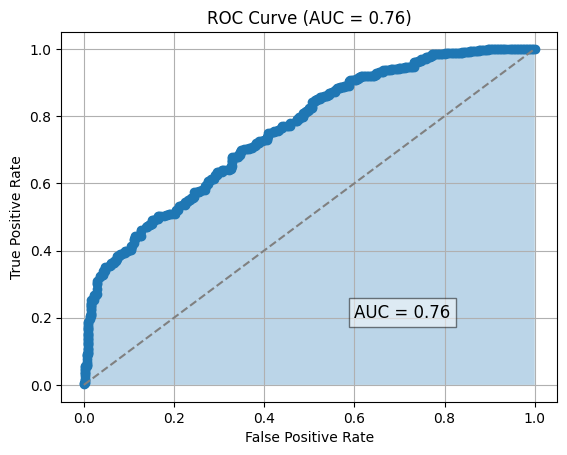

In [36]:
print("ROC Points:", roc_points)
print("AUC:", auc)

# Plot ROC curve
x, y = zip(*roc_points)
plt.plot(x, y, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') 
plt.fill_between(x, y, alpha=0.3) 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.2f})')

# Show grid
plt.grid(True)

# Add AUC value to plot
plt.text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Show plot
plt.show()

### Penjelasan

1. Hasil Confusion Matrix

Dari total 600 data pengujian, model berhasil memprediksi dengan benar 201 data kelas 0 dan 196 kelas 1, sementara 97 data kelas 0 salah diprediksi sebagai kelas 1 dan 106 data kelas 1 salah diprediksi sebagai kelas 0.

2. Hasil Precision, Recall, F1-Score, Accuracy per kelas

Untuk kelas 0, model memiliki precision 0,6547 dan recall 0,6745 dengan F1-score 0,6645. Untuk kelas 1, model memiliki precision 0,6689 dan recall 0,6490 dengan F1-score 0,6588.

3. Hasil Average F1-Score dan Average Accuracy

Rata-rata F1-score dari kedua kelas adalah 0,6616.
Rata-rata akurasi model sebesar 0,6617.

4. Hasil MCC per kelas

Matthews Correlation Coefficient (MCC) bernilai 0,3236 (1 prediksi sempurna, 0 prediksi acak, -1 prediksi salah).

5. Hasil ROC-AUC

Nilai Area Under the ROC Curve (AUC) sebesar 0,7566.